# Project 2 - Delta Air Lines Arrival Delay Analysis at SFO (2024) 

## Introduction
***Programming for Analytics - Project 2***. In this project, I analyze arrival delay data for Delta Air Lines (DL) flights arriving at San Francisco International Airport (SFO) during 2024. Using Python, Pandas, Matplotlib, and Seaborn, the goal is to explore how arrival delays behave throughout the year and identify the main operational factors that contributed to delays. The dataset was obtained from the U.S. Department of Transportation’s BTS Detailed Statistics - Arrivals tool. In addition to examining delay patterns, I also estimate the financial impact of avoidable delays by determining when Delta would be responsible for providing meal or hotel vouchers and calculating the total compensation cost using realistic industry passenger counts.

## Task
For this analysis, I wanted to continue exploring aviation topics but shift toward airline on-time performance. I collected Delta arrivals into SFO and examined scheduled vs. actual arrival times, delay durations, and the breakdown of delay categories. The objective is to determine ***what caused Delta delays the most in 2024***, and whether delays changed by month or by time of day. In addition, I extended the analysis by identifying which delays were avoidable from the airline’s perspective and estimating how much Delta would have spent on meal and hotel vouchers as a result, using realistic passenger counts and industry-based compensation assumptions.

## Data Dictionary
##### Purpose: 
Analyze arrival delay behavior for Delta Air Lines flights landing at SFO during 2024 to determine the major contributors to late arrivals.

##### Source:
U.S. Department of Transportation - BTS TranStats 
Dataset: "Detailed Statistics - Arrivals"
Filters Used:
- Airline: Delta Air Lines (DL)
- Destination Airport: San Francisco International (SFO)
- Year: 2024
- All months and all days
- All statistics enabled

##### Coverage:
January through December 2024
One row per flight arrival.

##### Primary Key:
None; each record represents a unique Delta arrival into SFO.

##### Fields After Renaming:
| Original Column Name                     | New Name (Python)         | Description                                    |
| ---------------------------------------- | ------------------------- | ---------------------------------------------- |
| Carrier Code                             | `carrier_code`            | Airline ID (Delta = DL)                        |
| Date (MM/DD/YYYY)                        | `flight_date`             | Date of the flight                             |
| Flight Num                               | `flight_number`           | Delta flight number                            |
| Tail Num                                 | `tail_number`             | Aircraft registration                          |
| Origin Airport                           | `origin_airport`          | Departure airport                              |
| Scheduled Arrival Time                   | `sched_arr_time`          | Planned arrival time (HH:MM)                   |
| Actual Arrival Time                      | `actual_arr_time`         | Actual arrival time (HH:MM)                    |
| Scheduled Elapsed Time (Minutes)         | `sched_elapsed_min`       | Planned gate-to-gate duration                  |
| Actual Elapsed Time (Minutes)            | `actual_elapsed_min`      | Actual gate-to-gate duration                   |
| Arrival Delay (Minutes)                  | `arr_delay_min`           | Delay in minutes (negative = early)            |
| Wheels-on Time                           | `wheels_on_time`          | Touchdown time                                 |
| Taxi-In time (Minutes)                   | `taxi_in_min`             | Minutes taxiing to the gate                    |
| Delay Carrier (Minutes)                  | `delay_carrier_min`       | Operational / staffing / equipment delays      |
| Delay Weather (Minutes)                  | `delay_weather_min`       | Delays caused by weather at origin/destination |
| Delay National Aviation System (Minutes) | `delay_nas_min`           | ATC/airspace congestion delays                 |
| Delay Security (Minutes)                 | `delay_security_min`      | Delays from security processes                 |
| Delay Late Aircraft Arrival (Minutes)    | `delay_late_aircraft_min` | Downstream delay passed from prior leg         |



# Data Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Detailed_Statistics_Arrivals (2024).csv", skiprows=7)

df = df.rename(columns={
    "Carrier Code": "carrier_code",
    "Date (MM/DD/YYYY)": "flight_date",
    "Flight Number": "flight_number",
    "Tail Number": "tail_number",
    "Origin Airport": "origin_airport",
    "Scheduled Arrival Time": "sched_arr_time",
    "Actual Arrival Time": "actual_arr_time",
    "Scheduled Elapsed Time (Minutes)": "sched_elapsed_min",
    "Actual Elapsed Time (Minutes)": "actual_elapsed_min",
    "Arrival Delay (Minutes)": "arr_delay_min",
    "Wheels-on Time": "wheels_on_time",
    "Taxi-In time (Minutes)": "taxi_in_min",
    "Delay Carrier (Minutes)": "delay_carrier_min",
    "Delay Weather (Minutes)": "delay_weather_min",
    "Delay National Aviation System (Minutes)": "delay_nas_min",
    "Delay Security (Minutes)": "delay_security_min",
    "Delay Late Aircraft Arrival (Minutes)": "delay_late_aircraft_min"
})

df["flight_date"] = pd.to_datetime(df["flight_date"])
df = df[:-1]#removing the last row of the dataset 
df


,carrier_code,flight_date,flight_number,tail_number,origin_airport,sched_arr_time,actual_arr_time,sched_elapsed_min,actual_elapsed_min,arr_delay_min,wheels_on_time,taxi_in_min,delay_carrier_min,delay_weather_min,delay_nas_min,delay_security_min,delay_late_aircraft_min
0,DL,2024-01-01,324.0,N194DN,ATL,12:51,12:22,326.0,298.0,-29.0,12:16,6.0,0.0,0.0,0.0,0.0,0.0
1,DL,2024-01-01,361.0,N923DZ,DTW,11:06,10:27,331.0,287.0,-39.0,10:22,5.0,0.0,0.0,0.0,0.0,0.0
2,DL,2024-01-01,469.0,N889DN,DTW,15:03,14:13,317.0,270.0,-50.0,14:06,7.0,0.0,0.0,0.0,0.0,0.0
3,DL,2024-01-01,536.0,N706TW,JFK,19:56,19:40,421.0,353.0,-16.0,19:35,5.0,0.0,0.0,0.0,0.0,0.0
4,DL,2024-01-01,656.0,N865DN,ATL,23:52,23:43,327.0,299.0,-9.0,23:38,5.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12875,DL,2024-12-31,2074.0,N374NW,MSP,13:55,13:48,263.0,265.0,-7.0,13:39,9.0,0.0,0.0,0.0,0.0,0.0
12876,DL,2024-12-31,2078.0,N869DN,MSP,11:14,10:54,259.0,244.0,-20.0,10:51,3.0,0.0,0.0,0.0,0.0,0.0
12877,DL,2024-12-31,2267.0,N328NW,LAX,15:47,15:34,87.0,67.0,-13.0,15:31,3.0,0.0,0.0,0.0,0.0,0.0
12878,DL,2024-12-31,2272.0,N345NW,LAX,11:39,11:12,99.0,74.0,-27.0,11:03,9.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#Cleaning the data
delay_cols = [
    "arr_delay_min",
    "delay_carrier_min",
    "delay_weather_min",
    "delay_nas_min",
    "delay_security_min",
    "delay_late_aircraft_min"
]

for col in delay_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0) #errors ="coerce" converts non-numeric to NaN, then fillna(0) replaces NaN with 0
    df[col] = df[col].clip(lower=0)  #Setting negative delays to 0

time_cols = ["sched_elapsed_min", "actual_elapsed_min", "taxi_in_min"]
for col in time_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce") #converting to numeric data type so calculations can be performed

df["month"] = df["flight_date"].dt.month

df["actual_arr_hour"] = df["actual_arr_time"].str.split(":").str[0].astype(int) #extracting hour from actial arrival time

df.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12880 entries, 0 to 12879
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   carrier_code             12880 non-null  object        
 1   flight_date              12880 non-null  datetime64[ns]
 2   flight_number            12880 non-null  float64       
 3   tail_number              12880 non-null  object        
 4   origin_airport           12880 non-null  object        
 5   sched_arr_time           12880 non-null  object        
 6   actual_arr_time          12880 non-null  object        
 7   sched_elapsed_min        12880 non-null  float64       
 8   actual_elapsed_min       12880 non-null  float64       
 9   arr_delay_min            12880 non-null  float64       
 10  wheels_on_time           12880 non-null  object        
 11  taxi_in_min              12880 non-null  float64       
 12  delay_carrier_min        12880 n

In [ ]:
df.describe().T 

,count,mean,min,25%,50%,75%,max,std
flight_date,12880,2024-07-06 17:34:03.726707968,2024-01-01 00:00:00,2024-04-15 00:00:00,2024-07-09 00:00:00,2024-09-30 00:00:00,2024-12-31 00:00:00,NaN
flight_number,12880.0,1134.732997,304.0,550.0,884.0,1559.0,8812.0,748.56681
sched_elapsed_min,12880.0,251.761102,75.0,127.0,296.0,331.0,436.0,119.290187
actual_elapsed_min,12880.0,244.235171,0.0,123.0,282.0,337.0,505.0,118.118308
arr_delay_min,12880.0,17.618866,0.0,0.0,0.0,17.0,1106.0,46.138566
taxi_in_min,12880.0,7.393789,0.0,5.0,6.0,8.0,92.0,5.571303
delay_carrier_min,12880.0,6.268634,0.0,0.0,0.0,0.0,1051.0,37.076339
delay_weather_min,12880.0,0.287655,0.0,0.0,0.0,0.0,266.0,5.362931
delay_nas_min,12880.0,7.022671,0.0,0.0,0.0,0.0,400.0,21.437199
delay_security_min,12880.0,0.004193,0.0,0.0,0.0,0.0,54.0,0.475812


## Distribution of Arrival Delays

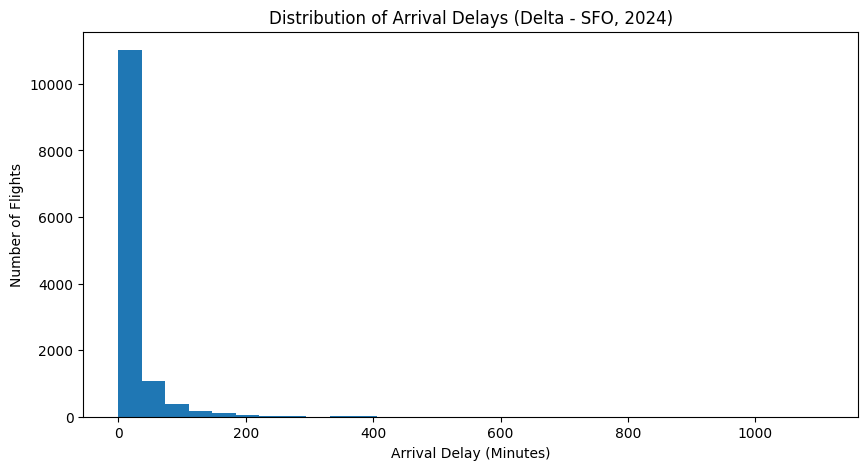

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(df["arr_delay_min"], bins=30)#plotting histogram of arrival delays
plt.title("Distribution of Arrival Delays (Delta - SFO, 2024)")
plt.xlabel("Arrival Delay (Minutes)")
plt.ylabel("Number of Flights")
plt.show()


## Average Arrival Delay by Month   

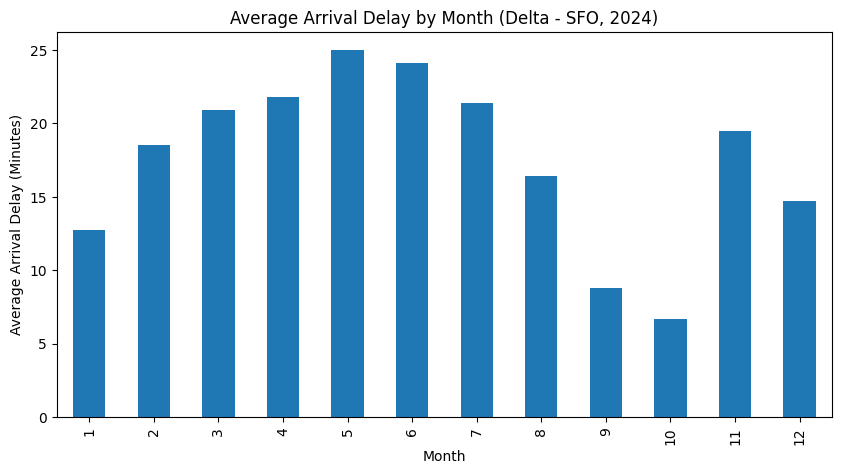

In [ ]:
avg_delay_month = df.groupby("month")["arr_delay_min"].mean()#grouping by month to find average delay by month

plt.figure(figsize=(10,5))
avg_delay_month.plot(kind="bar")
plt.title("Average Arrival Delay by Month (Delta - SFO, 2024)")
plt.xlabel("Month")
plt.ylabel("Average Arrival Delay (Minutes)")
plt.show()


## Average Arrival Delay by Hour of Day

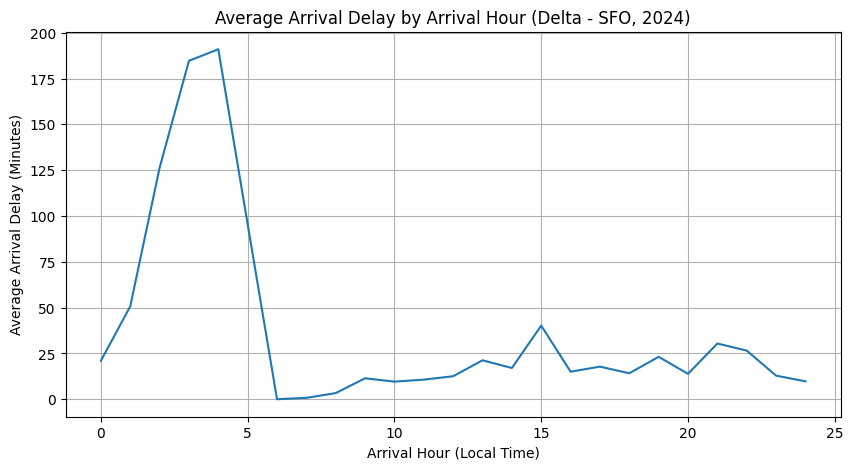

In [ ]:
avg_delay_hour = df.groupby("actual_arr_hour")["arr_delay_min"].mean()#grouping by actual arrival hour to find average delay by hour

plt.figure(figsize=(10,5))
avg_delay_hour.plot()
plt.title("Average Arrival Delay by Arrival Hour (Delta - SFO, 2024)")
plt.xlabel("Arrival Hour (Local Time)")
plt.ylabel("Average Arrival Delay (Minutes)")
plt.grid(True)
plt.show()


## Total Delay Minutes by Cause

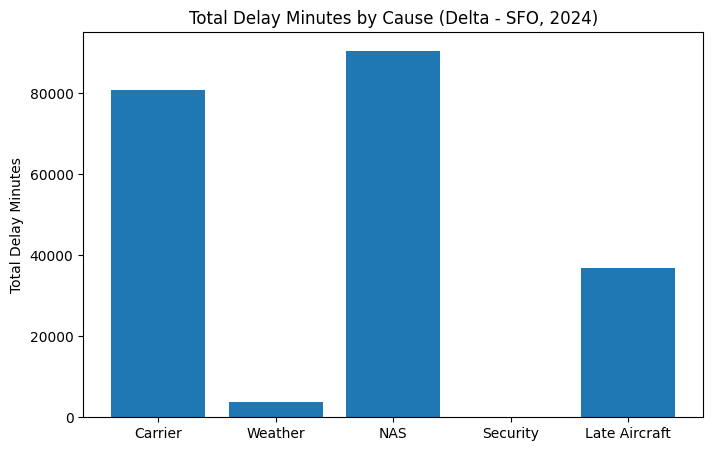

{'Carrier': np.float64(80740.0),
 'Weather': np.float64(3705.0),
 'NAS': np.float64(90452.0),
 'Security': np.float64(54.0),
 'Late Aircraft': np.float64(36711.0)}

In [ ]:
cause_totals = {
    "Carrier": df["delay_carrier_min"].sum(),
    "Weather": df["delay_weather_min"].sum(),
    "NAS": df["delay_nas_min"].sum(),
    "Security": df["delay_security_min"].sum(),
    "Late Aircraft": df["delay_late_aircraft_min"].sum()
}#summing up total delay minutes by cause

plt.figure(figsize=(8,5))
plt.bar(cause_totals.keys(), cause_totals.values())
plt.title("Total Delay Minutes by Cause (Delta - SFO, 2024)")
plt.ylabel("Total Delay Minutes")
plt.show()
cause_totals


## Heatmap of Average Arrival Delay by Month and Hour

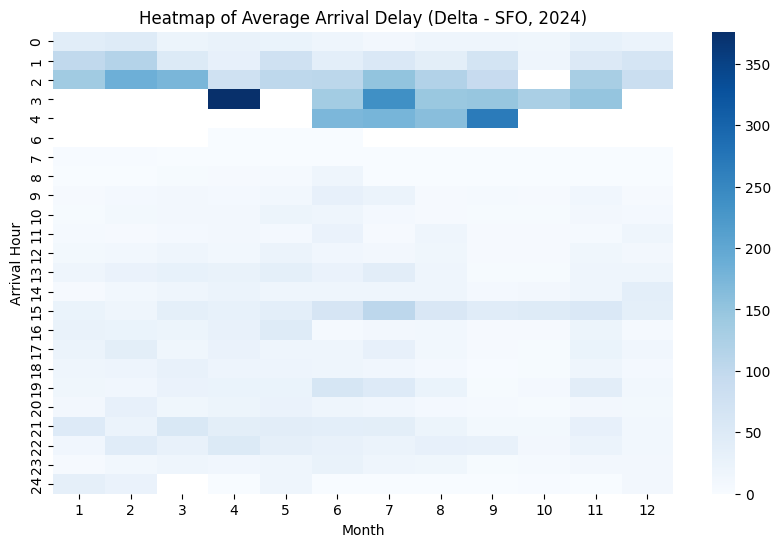

In [ ]:
pivot = df.pivot_table(
    index="actual_arr_hour",
    columns="month",
    values="arr_delay_min",
    aggfunc="mean"
)#creating a pivot table to prepare the data for a heatmap

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="Blues")
plt.title("Heatmap of Average Arrival Delay (Delta - SFO, 2024)")
plt.xlabel("Month")
plt.ylabel("Arrival Hour")
plt.show()


## Top 5 Origin Airports by Average Arrival Delay at SFO

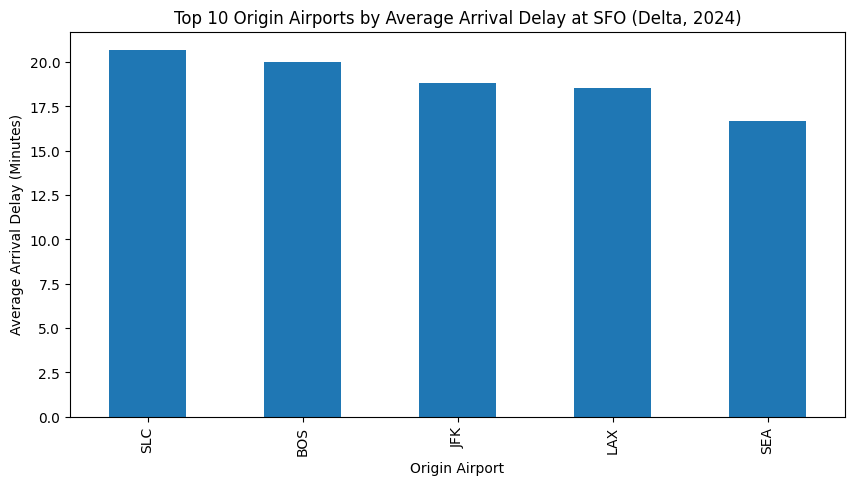

origin_airport
SLC    20.680357
BOS    20.028205
JFK    18.825256
LAX    18.529983
SEA    16.705788
Name: arr_delay_min, dtype: float64

In [ ]:
origin_delay = (
    df.groupby("origin_airport")["arr_delay_min"]
      .mean()
      .sort_values(ascending=False)
      .head(5)
)#finding top 5 origin airports by average arrival delay

plt.figure(figsize=(10,5))
origin_delay.plot(kind="bar")
plt.title("Top 10 Origin Airports by Average Arrival Delay at SFO (Delta, 2024)")
plt.xlabel("Origin Airport")
plt.ylabel("Average Arrival Delay (Minutes)")
plt.show()

origin_delay


## Estimated Compensation Cost for Avoidable Delays for Delta Air Lines in 2024 Only from SFO Arrivals


In [25]:
def compensation_cost(
    df,
    passengers_per_flight=140,
    food_cost_per_passenger=30,
    hotel_cost_per_passenger=150,
    food_threshold_min=180,      #3 hours
    hotel_threshold_min=360      #6+ hours = overnight severity
):
    """
    Estimate Delta's total compensation cost for avoidable delays at SFO in 2024.
    Realistic industry passenger count assumptions.
    """

    result = df.copy()

    #Avoidable(controllable) delay minutes
    result["avoidable_delay_min"] = (
        result["delay_carrier_min"] + result["delay_late_aircraft_min"]
    )
    #Determining voucher type per flight
    def classify(mins):
        if mins < food_threshold_min:
            return "None"
        elif mins < hotel_threshold_min:
            return "Food"
        else:
            return "Food+Hotel"

    result["voucher_type"] = result["avoidable_delay_min"].apply(classify)
    #Cost per passenger - cost per flight
    def voucher_cost(vtype):
        if vtype == "Food":
            return passengers_per_flight * food_cost_per_passenger
        elif vtype == "Food+Hotel":
            return passengers_per_flight * (food_cost_per_passenger + hotel_cost_per_passenger)
        else:
            return 0

    result["voucher_cost"] = result["voucher_type"].apply(voucher_cost)

    #Summary of voucher types
    summary = result.groupby("voucher_type")["voucher_cost"].agg(
        flights="count",
        total_cost="sum"
    )

    #Total yearly cost
    total_cost_2024 = result["voucher_cost"].sum()

    return result, summary, total_cost_2024

voucher_df, voucher_summary, total_voucher_cost = compensation_cost(df)

voucher_summary
print(f"Total estimated voucher cost for Delta - SFO in 2024: ${total_voucher_cost:,.2f}")



Total estimated voucher cost for Delta - SFO in 2024: $1,012,200.00


## Discussion of the findings
Based on the analysis of Delta Air Lines arrival delays at SFO in 2024, several key findings emerged:

- Most flights arrived close to on time, but the delay distribution was highly skewed due to a small number of major outliers.

- Delays peaked during late spring and early summer, with May and June showing the highest averages.

- Extremely high average delays occurred in the early-morning hours, largely from overnight disruptions rolling into the next day.

- NAS (airspace congestion) and carrier-related issues were the largest contributors to total delay minutes, while weather and security delays were minimal.

- Flights from major origin airports like SLC, BOS, and JFK showed the highest average arrival delays.

- Using a realistic compensation model, avoidable delays would have cost Delta over $1 million in food and hotel vouchers for these SFO arrivals in 2024.


## Conclusion
In conclusion, the analysis of Delta Air Lines arrival delays at SFO in 2024 revealed significant insights into delay patterns and their causes. While most flights arrived on time, a few extreme delays skewed the average, particularly during peak months and early morning hours. The primary contributors to delays were airspace congestion and carrier-related issues, highlighting areas for potential operational improvements. Additionally, the financial impact of avoidable delays was substantial, emphasizing the importance of effective delay management strategies. Overall, this analysis provides valuable information for Delta to enhance its on-time performance and reduce passenger inconvenience in the future.